Saving iris.csv to iris (1).csv
Dataset Preview:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Clustered Data:
   sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        2
2           4.7          3.2           1.3          0.2  Iris-setosa        2
3           4.6          3.1           1.5          0.2  Iris-setosa        2
4           5.0          3.6           1.4          0.2  Iris-setosa        1


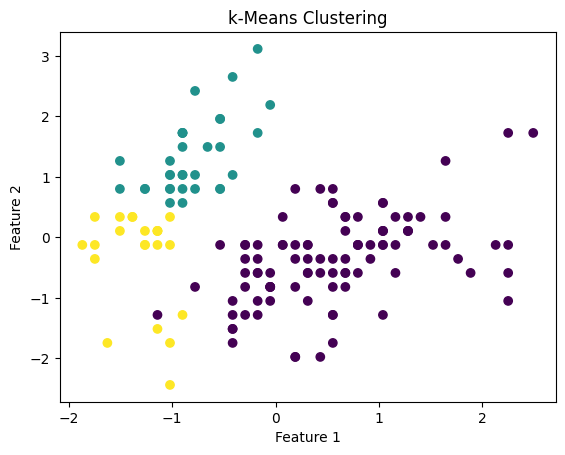


Centroids:
[[ 0.57100359 -0.36600236  0.69108416  0.66322635]
 [-0.80601877  1.33577362 -1.28618375 -1.21026347]
 [-1.31926109 -0.34584225 -1.14482725 -1.1336954 ]]


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Upload CSV file
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Display first few rows
print("Dataset Preview:")
print(df.head())

# Step 4: Data Preprocessing
# Drop non-numeric columns if present (like species in Iris)
df_numeric = df.select_dtypes(include=[np.number])

# Handle missing values if any
df_numeric = df_numeric.dropna()

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)

# Step 5: Apply k-Means
k = 3  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_

# Step 6: Add cluster labels to dataset
df['Cluster'] = labels

print("\nClustered Data:")
print(df.head())

# Step 7: Visualize clusters (using first two features)
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("k-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Step 8: Print centroids
print("\nCentroids:")
print(kmeans.cluster_centers_)